In [ ]:
pics_list = [
    "DSCF4673.jpg",
    "DSCF4675.jpg",
    "DSCF4653.jpg",
    "DSCF4646.jpg",
    "DSCF3780.jpg",
    "DSCF3783.jpg",
    "DSCF3790.jpg",
    "DSCF3817.jpg",
    "DSCF3862.jpg",
    "DSCF3856.jpg",
    "DSCF3892.jpg",
    "DSCF3974.jpg",
    "DSCF3977.jpg",
    "DSCF3980.jpg",
    "DSCF4037.jpg",
    "DSCF4045.jpg",
    "DSCF4085.jpg",
    "DSCF4094.jpg",
    "DSCF4133.jpg",
    "DSCF4141.jpg",
    "DSCF4181.jpg",
    "DSCF4196.jpg",
    "DSCF4358.jpg",
    "DSCF4364.jpg",
    "DSCF4365.jpg",
    "DSCF4368.jpg",
    "DSCF4369.jpg",
    "DSCF4376.jpg",
    "DSCF4390.jpg",
    "DSCF4430.jpg",
    "DSCF4462.jpg",
    "DSCF4487.jpg",
    "DSCF4513.jpg",
    "DSCF4524.jpg",
    "DSCF4530.jpg",
    "DSCF4545.jpg",
    "DSCF4551.jpg",
    "DSCF4569.jpg",
    "DSCF4577.jpg",
    "DSCF4579.jpg",
    "DSCF4586.jpg",
    "DSCF4905.jpg",
    "DSCF4938.jpg",
    "DSCF4955.jpg",
    "DSCF5112.jpg",
    "DSCF5153.jpg",
    "DSCF5122.jpg",
    "DSCF5187.jpg",
    "DSCF5196.jpg",
    "DSCF5200.jpg",
    "DSCF5246.jpg",
    "DSCF5293.jpg",
    "DSCF5308.jpg",
    "DSCF5342.jpg",
    "DSCF5403.jpg",
]
concat_str = ""
for pic in pics_list:
    concat_str += f" {pic} OR"
concat_str

' DSCF4673.jpg OR DSCF4675.jpg OR DSCF4653.jpg OR DSCF4646.jpg OR DSCF3780.jpg OR DSCF3783.jpg OR DSCF3790.jpg OR DSCF3817.jpg OR DSCF3862.jpg OR DSCF3856.jpg OR DSCF3892.jpg OR DSCF3974.jpg OR DSCF3977.jpg OR DSCF3980.jpg OR DSCF4037.jpg OR DSCF4045.jpg OR DSCF4085.jpg OR DSCF4094.jpg OR DSCF4133.jpg OR DSCF4141.jpg OR DSCF4181.jpg OR DSCF4196.jpg OR DSCF4358.jpg OR DSCF4364.jpg OR DSCF4365.jpg OR DSCF4368.jpg OR DSCF4369.jpg OR DSCF4376.jpg OR DSCF4390.jpg OR DSCF4430.jpg OR DSCF4462.jpg OR DSCF4487.jpg OR DSCF4513.jpg OR DSCF4524.jpg OR DSCF4530.jpg OR DSCF4545.jpg OR DSCF4551.jpg OR DSCF4569.jpg OR DSCF4577.jpg OR DSCF4579.jpg OR DSCF4586.jpg OR DSCF4905.jpg OR DSCF4938.jpg OR DSCF4955.jpg OR DSCF5112.jpg OR DSCF5153.jpg OR DSCF5122.jpg OR DSCF5187.jpg OR DSCF5196.jpg OR DSCF5200.jpg OR DSCF5246.jpg OR DSCF5293.jpg OR DSCF5308.jpg OR DSCF5342.jpg OR DSCF5403.jpg OR'

In [ ]:
from datetime import datetime
import pandas as pd
current_market = int(pd.Timestamp(datetime.utcnow(), unit="s").ceil("15min").timestamp())
current_market

C:\Users\zhatz\AppData\Local\Temp\ipykernel_31924\3376668957.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  current_market = int(pd.Timestamp(datetime.utcnow(), unit="s").ceil("15min").timestamp())


1769638500

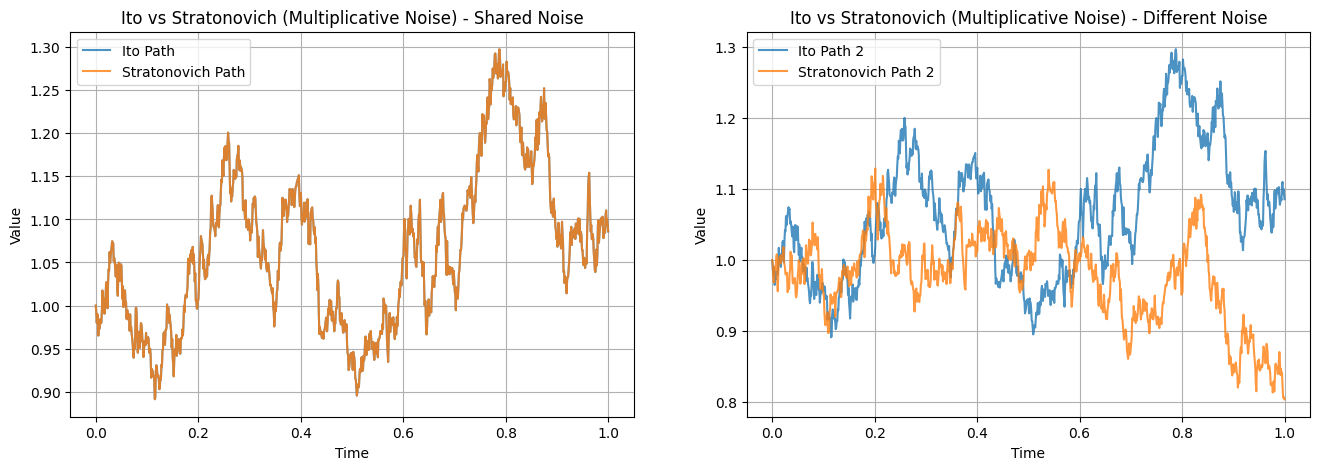

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu = 0.5
sigma = 0.4
T = 1.0
dt = 0.001
steps = int(T / dt)
t = np.linspace(0, T, steps)

# Initialize paths
x0 = 1.0
x_ito = np.zeros(steps)
x_strat = np.zeros(steps)
x_ito2 = np.zeros(steps)
x_strat2 = np.zeros(steps)
x_ito[0] = x_strat[0] = x0
x_ito2[0] = x_strat2[0] = x0

# Generate different Brownian noise
dw = np.random.normal(0, np.sqrt(dt), steps)
dw2 = np.random.normal(0, np.sqrt(dt), steps)

for i in range(1, steps):
    # Ito Integration (Left-point rule)
    x_ito[i] = x_ito[i-1] + mu*x_ito[i-1]*dt + sigma*x_ito[i-1]*dw[i]
    x_ito2[i] = x_ito2[i-1] + mu*x_ito2[i-1]*dt + sigma*x_ito2[i-1]*dw[i]

    # Stratonovich Integration (Mid-point rule/Trapezoidal)
    # We use a predictor-corrector style or the Ito-drift conversion
    # For clarity, let's use the drift conversion: Strat = Ito + 0.5 * sigma^2 * X
    drift_correction = 0.5 * (sigma**2) * x_strat[i-1] * dt
    x_strat[i] = x_strat[i-1] + (mu*x_strat[i-1] + drift_correction)*dt + sigma*x_strat[i-1]*dw[i]
    x_strat2[i] = x_strat2[i-1] + (mu*x_strat2[i-1] + drift_correction)*dt + sigma*x_strat2[i-1]*dw2[i]

fig, axes = plt.subplots(1,2,figsize=(16, 5))
axes[0].plot(t, x_ito, label='Ito Path', alpha=0.8)
axes[0].plot(t, x_strat, label='Stratonovich Path', alpha=0.8)
axes[1].plot(t, x_ito2, label='Ito Path 2', alpha=0.8)
axes[1].plot(t, x_strat2, label='Stratonovich Path 2', alpha=0.8)
axes[0].set_title("Ito vs Stratonovich (Multiplicative Noise) - Shared Noise")
axes[1].set_title("Ito vs Stratonovich (Multiplicative Noise) - Different Noise")
axes[0].set_xlabel("Time")
axes[1].set_xlabel("Time")
axes[0].set_ylabel("Value")
axes[1].set_ylabel("Value")
axes[0].legend()
axes[1].legend()
axes[0].grid(True)
axes[1].grid(True)
plt.show()

### Code Upskilling

In [43]:
import pandas as pd
import numpy as np

prices = pd.DataFrame({
    'ticker': ['AAPL','AAPL','AAPL','AAPL','AAPL',
               'MSFT','MSFT','MSFT','MSFT','MSFT'],
    'date': pd.to_datetime(['2024-01-01','2024-01-02','2024-01-03',
                            '2024-01-04','2024-01-05'] * 2),
    'price': [150, 153, 151, 156, 158, 300, 295, 298, 302, 305],
    'volume': [1000, 1200, 900, 1100, 1300, 500, 480, 520, 510, 490]
})

metadata = pd.DataFrame({
    'ticker': ['AAPL', 'MSFT', 'GOOG'],
    'sector': ['Tech', 'Tech', 'Tech'],
    'market_cap': ['Large', 'Large', 'Large']
})
display(metadata)
display(prices)

,ticker,sector,market_cap
0,AAPL,Tech,Large
1,MSFT,Tech,Large
2,GOOG,Tech,Large


,ticker,date,price,volume
0,AAPL,2024-01-01,150,1000
1,AAPL,2024-01-02,153,1200
2,AAPL,2024-01-03,151,900
3,AAPL,2024-01-04,156,1100
4,AAPL,2024-01-05,158,1300
5,MSFT,2024-01-01,300,500
6,MSFT,2024-01-02,295,480
7,MSFT,2024-01-03,298,520
8,MSFT,2024-01-04,302,510
9,MSFT,2024-01-05,305,490


In [9]:
# Problem 1
# 1.1
left_join = metadata.merge(prices, on="ticker", how="left", indicator=True)
# 1.2
left_join.loc[left_join["_merge"]=="left_only", "ticker"].iloc[0]
# 1.3
prices[prices["ticker"]=="AAPL"].merge(prices[prices["ticker"]=="MSFT"], on="date", how="inner", suffixes=("_aapl", "_msft"))

,ticker_aapl,date,price_aapl,volume_aapl,ticker_msft,price_msft,volume_msft
0,AAPL,2024-01-01,150,1000,MSFT,300,500
1,AAPL,2024-01-02,153,1200,MSFT,295,480
2,AAPL,2024-01-03,151,900,MSFT,298,520
3,AAPL,2024-01-04,156,1100,MSFT,302,510
4,AAPL,2024-01-05,158,1300,MSFT,305,490


In [26]:
# Problem 2
# 2.1
pivot = prices.pivot(index="date", columns="ticker", values="price")
# 2.2
pivot.melt(id_vars=list(pivot.columns), var_name="ticker", value_name="price")
# 2.3
prices["price_bucket"] = pd.cut(prices['price'], bins=3)
prices["mean_per_ticker_per_price"] = prices.groupby(["ticker", "price_bucket"])["volume"].transform("mean")
prices

C:\Users\zhatz\AppData\Local\Temp\ipykernel_61856\1948411952.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prices["mean_per_ticker_per_price"] = prices.groupby(["ticker", "price_bucket"])["volume"].transform("mean")


,ticker,date,price,volume,price_bucket,mean_per_ticker_per_price
0,AAPL,2024-01-01,150,1000,"(149.845, 201.667]",1100.0
1,AAPL,2024-01-02,153,1200,"(149.845, 201.667]",1100.0
2,AAPL,2024-01-03,151,900,"(149.845, 201.667]",1100.0
3,AAPL,2024-01-04,156,1100,"(149.845, 201.667]",1100.0
4,AAPL,2024-01-05,158,1300,"(149.845, 201.667]",1100.0
5,MSFT,2024-01-01,300,500,"(253.333, 305.0]",500.0
6,MSFT,2024-01-02,295,480,"(253.333, 305.0]",500.0
7,MSFT,2024-01-03,298,520,"(253.333, 305.0]",500.0
8,MSFT,2024-01-04,302,510,"(253.333, 305.0]",500.0
9,MSFT,2024-01-05,305,490,"(253.333, 305.0]",500.0


In [36]:
# Problem 3
# 3.1
prices["daily_return"] = prices.groupby("ticker")["price"].pct_change()
# 3.2
prices["rolling_avg"] = prices.groupby("ticker")["price"].transform(lambda x: x.rolling(3).mean())
# 3.3
prices["cum_avg"] = prices.groupby("ticker")["price"].transform(lambda x: x.expanding().mean())
# 3.4
prices["flag"] = prices["price"] > prices["rolling_avg"]
prices

,ticker,date,price,volume,daily_return,rolling_avg,cum_avg,flag
0,AAPL,2024-01-01,150,1000,NaN,NaN,150.000000,False
1,AAPL,2024-01-02,153,1200,0.020000,NaN,151.500000,False
2,AAPL,2024-01-03,151,900,-0.013072,151.333333,151.333333,False
3,AAPL,2024-01-04,156,1100,0.033113,153.333333,152.500000,True
4,AAPL,2024-01-05,158,1300,0.012821,155.000000,153.600000,True
5,MSFT,2024-01-01,300,500,NaN,NaN,300.000000,False
6,MSFT,2024-01-02,295,480,-0.016667,NaN,297.500000,False
7,MSFT,2024-01-03,298,520,0.010169,297.666667,297.666667,True
8,MSFT,2024-01-04,302,510,0.013423,298.333333,298.750000,True
9,MSFT,2024-01-05,305,490,0.009934,301.666667,300.000000,True


In [47]:
# Problem 4
# inner join prices onto metadata to get rid of non-matching rows
pipeline = metadata.merge(prices, on="ticker", how="inner")
pipeline["rolling_return"] = pipeline.groupby("ticker")["price"].transform(lambda x: x.rolling(3, min_periods=1).mean().pct_change())
pipeline.pivot(columns="ticker", index="date")

sector       market_cap        price      volume       \
ticker       AAPL  MSFT       AAPL   MSFT  AAPL MSFT   AAPL MSFT   
date                                                               
2024-01-01   Tech  Tech      Large  Large   150  300   1000  500   
2024-01-02   Tech  Tech      Large  Large   153  295   1200  480   
2024-01-03   Tech  Tech      Large  Large   151  298    900  520   
2024-01-04   Tech  Tech      Large  Large   156  302   1100  510   
2024-01-05   Tech  Tech      Large  Large   158  305   1300  490   

           rolling_return            
ticker               AAPL      MSFT  
date                                 
2024-01-01            NaN       NaN  
2024-01-02       0.010000 -0.008333  
2024-01-03      -0.001100  0.000560  
2024-01-04       0.013216  0.002240  
2024-01-05       0.010870  0.011173

In [ ]:
# My Solutions

# Problem 1
# 1.1
left_join = metadata.merge(prices, on="ticker", how="left", indicator=True)
# 1.2
left_join.loc[left_join["_merge"]=="left_only", "ticker"].iloc[0]
# 1.3
prices[prices["ticker"]=="AAPL"].merge(prices[prices["ticker"]=="MSFT"], on="date", how="inner", suffixes=("_aapl", "_msft"))

# Problem 2
# 2.1
pivot = prices.pivot(index="date", columns="ticker", values="price")
# 2.2
pivot.melt(id_vars=list(pivot.columns), var_name="ticker", value_name="price")
# 2.3
prices["price_bucket"] = pd.cut(prices['price'], bins=3)
prices["mean_per_ticker_per_price"] = prices.groupby(["ticker", "price_bucket"])["volume"].transform("mean")

# Problem 3
# 3.1
prices["daily_return"] = prices.groupby("ticker")["price"].pct_change()
# 3.2
prices["rolling_avg"] = prices.groupby("ticker")["price"].transform(lambda x: x.rolling(3).mean())
# 3.3
prices["cum_avg"] = prices.groupby("ticker")["price"].transform(lambda x: x.expanding().mean())
# 3.4
prices["flag"] = prices["price"] > prices["rolling_avg"]

# Problem 4
# inner join prices onto metadata to get rid of non-matching rows
pipeline = metadata.merge(prices, on="ticker", how="inner")
pipeline["rolling_return"] = pipeline.groupby("ticker")["price"].transform(lambda x: x.rolling(3, min_periods=1).mean().pct_change())
pipeline.pivot(columns="ticker", index="date")